# Учимся работе с данными - от загрузки до моделирования

In [4]:
#YOUR CODE HERE
#1.Скачайте датасет по ссылке: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data
import kagglehub
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

dc = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')
df = dc.copy()
df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
#2.базовые статистики датасета
print("Размер датасета:", df.shape)
print("\nзначения целевой переменной:")
print(df['diagnosis'].unique())
print("\nПроверка на пропуски:")
print(df.isnull().sum())



Размер датасета: (569, 33)

значения целевой переменной:
['M' 'B']

Проверка на пропуски:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave poi

Распределение целевой переменной:
diagnosis
B    357
M    212
Name: count, dtype: int64


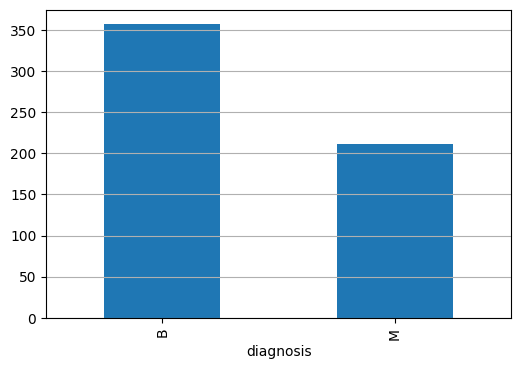

In [6]:

print(f"Распределение целевой переменной:\n{df['diagnosis'].value_counts()}")
df['diagnosis'].value_counts().plot.bar(figsize=(6, 4))
plt.grid(axis='y')
plt.show()

In [7]:
if 'id' in dc.columns:
    df_clean = df.drop('id', axis=1)
else:
    df_clean = df.copy()
    print("Колонка 'id' не найдена!")
print(df_clean.head(1))


  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38           122.8     1001.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0           0.1184            0.2776          0.3001               0.1471   

   symmetry_mean  ...  texture_worst  perimeter_worst  area_worst  \
0         0.2419  ...          17.33            184.6      2019.0   

   smoothness_worst  compactness_worst  concavity_worst  concave points_worst  \
0            0.1622             0.6656           0.7119                0.2654   

   symmetry_worst  fractal_dimension_worst  Unnamed: 32  
0          0.4601                   0.1189          NaN  

[1 rows x 32 columns]


In [8]:
print(df_clean.head(1))

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38           122.8     1001.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0           0.1184            0.2776          0.3001               0.1471   

   symmetry_mean  ...  texture_worst  perimeter_worst  area_worst  \
0         0.2419  ...          17.33            184.6      2019.0   

   smoothness_worst  compactness_worst  concavity_worst  concave points_worst  \
0            0.1622             0.6656           0.7119                0.2654   

   symmetry_worst  fractal_dimension_worst  Unnamed: 32  
0          0.4601                   0.1189          NaN  

[1 rows x 32 columns]


In [9]:
df_clean['diagnosis_binary'] = df['diagnosis'].map({'B': 0, 'M': 1})
print(df_clean.head(1))

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38           122.8     1001.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0           0.1184            0.2776          0.3001               0.1471   

   symmetry_mean  ...  perimeter_worst  area_worst  smoothness_worst  \
0         0.2419  ...            184.6      2019.0            0.1622   

   compactness_worst  concavity_worst  concave points_worst  symmetry_worst  \
0             0.6656           0.7119                0.2654          0.4601   

   fractal_dimension_worst  Unnamed: 32  diagnosis_binary  
0                   0.1189          NaN                 1  

[1 rows x 33 columns]


In [10]:
print(df.head(1))
if 'diagnosis' and 'Unnamed: 32' in df.columns:
    df_clean1 = df_clean.drop('diagnosis', axis=1)
    df_clean2 = df_clean1.drop('Unnamed: 32', axis=1)
    df_clean = df_clean2

print(f"Индексы колонок:\n{df_clean.columns.tolist()}")

       id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0  842302         M        17.99         10.38           122.8     1001.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0           0.1184            0.2776          0.3001               0.1471   

   ...  texture_worst  perimeter_worst  area_worst  smoothness_worst  \
0  ...          17.33            184.6      2019.0            0.1622   

   compactness_worst  concavity_worst  concave points_worst  symmetry_worst  \
0             0.6656           0.7119                0.2654          0.4601   

   fractal_dimension_worst  Unnamed: 32  
0                   0.1189          NaN  

[1 rows x 33 columns]
Индексы колонок:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'comp

In [12]:
print(f"Индексы колонок:\n{df_clean.columns.tolist()}")

Индексы колонок:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'diagnosis_binary']


In [11]:
df_clean1= df_clean2 = 0


In [13]:
print(df_clean.head(1))

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38           122.8     1001.0           0.1184   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0            0.2776          0.3001               0.1471         0.2419   

   fractal_dimension_mean  ...  texture_worst  perimeter_worst  area_worst  \
0                 0.07871  ...          17.33            184.6      2019.0   

   smoothness_worst  compactness_worst  concavity_worst  concave points_worst  \
0            0.1622             0.6656           0.7119                0.2654   

   symmetry_worst  fractal_dimension_worst  diagnosis_binary  
0          0.4601                   0.1189                 1  

[1 rows x 31 columns]


In [14]:
print("\nИнформация о данных:")
print(df_clean.info())
print("\nСтатистическое описание:")
print(df_clean.describe())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoo

In [15]:
#2.1. средние, медианы etc...

print("🔄 СРАВНЕНИЕ СРЕДНИХ И МЕДИАН:")
comparison = pd.DataFrame({
    'Mean': df_clean.mean(),
    'Median': df_clean.median(),
    'Difference': df_clean.mean() - df_clean.median(),
    'Skewness': df_clean.skew()
})
print(comparison)


🔄 СРАВНЕНИЕ СРЕДНИХ И МЕДИАН:
                               Mean      Median  Difference  Skewness
radius_mean               14.127292   13.370000    0.757292  0.942380
texture_mean              19.289649   18.840000    0.449649  0.650450
perimeter_mean            91.969033   86.240000    5.729033  0.990650
area_mean                654.889104  551.100000  103.789104  1.645732
smoothness_mean            0.096360    0.095870    0.000490  0.456324
compactness_mean           0.104341    0.092630    0.011711  1.190123
concavity_mean             0.088799    0.061540    0.027259  1.401180
concave points_mean        0.048919    0.033500    0.015419  1.171180
symmetry_mean              0.181162    0.179200    0.001962  0.725609
fractal_dimension_mean     0.062798    0.061540    0.001258  1.304489
radius_se                  0.405172    0.324200    0.080972  3.088612
texture_se                 1.216853    1.108000    0.108853  1.646444
perimeter_se               2.866059    2.287000    0.579059 

In [16]:
# Статистика по классам диагноза
print("\n" + "="*60)
print("📊 СТАТИСТИКИ ПО КЛАССАМ ДИАГНОЗА:")
print(f"\nРаспределение классов:")
print(f"  Доброкачественные (B): {len(df_clean[df_clean['diagnosis_binary']==0])} ({(len(df_clean[df_clean['diagnosis_binary']==0])/len(df_clean)*100):.1f}%)")
print(f"  Злокачественные (M):   {len(df_clean[df_clean['diagnosis_binary']==1])} ({(len(df_clean[df_clean['diagnosis_binary']==1])/len(df_clean)*100):.1f}%)")

print("\nДоброкачественные (B):")
b_stats = df_clean[df_clean['diagnosis_binary']==0].describe()
print(f"  Средний радиус: {b_stats.loc['mean','radius_mean']:.2f}")
print(f"  Медианный радиус: {b_stats.loc['50%','radius_mean']:.2f}")
print(f"  Средняя площадь: {b_stats.loc['mean','area_mean']:.2f}")
print(f"  Медианная площадь: {b_stats.loc['50%','area_mean']:.2f}")
print(f"  Средняя площадь полости: {b_stats.loc['mean','concavity_mean']:.2f}")
print(f"  Медианная площадь полости: {b_stats.loc['50%','concavity_mean']:.2f}")

print("\nЗлокачественные (M):")
m_stats = df_clean[df_clean['diagnosis_binary']==1].describe()
print(f"  Средний радиус: {m_stats.loc['mean','radius_mean']:.2f}")
print(f"  Медианный радиус: {m_stats.loc['50%','radius_mean']:.2f}")
print(f"  Средняя площадь: {m_stats.loc['mean','area_mean']:.2f}")
print(f"  Медианная площадь: {m_stats.loc['50%','area_mean']:.2f}")
print(f"  Средняя площадь полости: {m_stats.loc['mean','concavity_mean']:.2f}")
print(f"  Медианная площадь полости: {m_stats.loc['50%','concavity_mean']:.2f}")


📊 СТАТИСТИКИ ПО КЛАССАМ ДИАГНОЗА:

Распределение классов:
  Доброкачественные (B): 357 (62.7%)
  Злокачественные (M):   212 (37.3%)

Доброкачественные (B):
  Средний радиус: 12.15
  Медианный радиус: 12.20
  Средняя площадь: 462.79
  Медианная площадь: 458.40
  Средняя площадь полости: 0.05
  Медианная площадь полости: 0.04

Злокачественные (M):
  Средний радиус: 17.46
  Медианный радиус: 17.33
  Средняя площадь: 978.38
  Медианная площадь: 932.00
  Средняя площадь полости: 0.16
  Медианная площадь полости: 0.15


In [17]:
# 8. Выбросы
print("\n" + "="*60)
print("🔍 АНАЛИЗ ВЫБРОСОВ")

for diagnosis_binary in [0, 1]:
    subset = df_clean[df_clean['diagnosis_binary'] == diagnosis_binary]
    name = 'Доброкачественные' if diagnosis_binary == 0 else 'Злокачественные'
    print(f"{name}:")
    for feature in ['radius_mean', 'area_mean', 'concavity_mean']:
      Q1 = subset[feature].quantile(0.25)
      Q3 = subset[feature].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      outliers = subset[(subset[feature] < lower_bound) | (subset[feature] > upper_bound)]
      print(f"{feature}:")
      print(f"  IQR: {IQR:.2f}")
      print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
      print(f"  Количество выбросов: {len(outliers)} ({(len(outliers)/len(df)*100):.1f}%)")
      print()


🔍 АНАЛИЗ ВЫБРОСОВ
Доброкачественные:
radius_mean:
  IQR: 2.29
  Границы: [7.65, 16.80]
  Количество выбросов: 3 (0.5%)

area_mean:
  IQR: 172.90
  Границы: [118.85, 810.45]
  Количество выбросов: 4 (0.7%)

concavity_mean:
  IQR: 0.04
  Границы: [-0.04, 0.12]
  Количество выбросов: 12 (2.1%)

Злокачественные:
radius_mean:
  IQR: 4.52
  Границы: [8.30, 26.36]
  Количество выбросов: 3 (0.5%)

area_mean:
  IQR: 498.45
  Границы: [-42.38, 1951.43]
  Количество выбросов: 4 (0.7%)

concavity_mean:
  IQR: 0.09
  Границы: [-0.03, 0.34]
  Количество выбросов: 6 (1.1%)



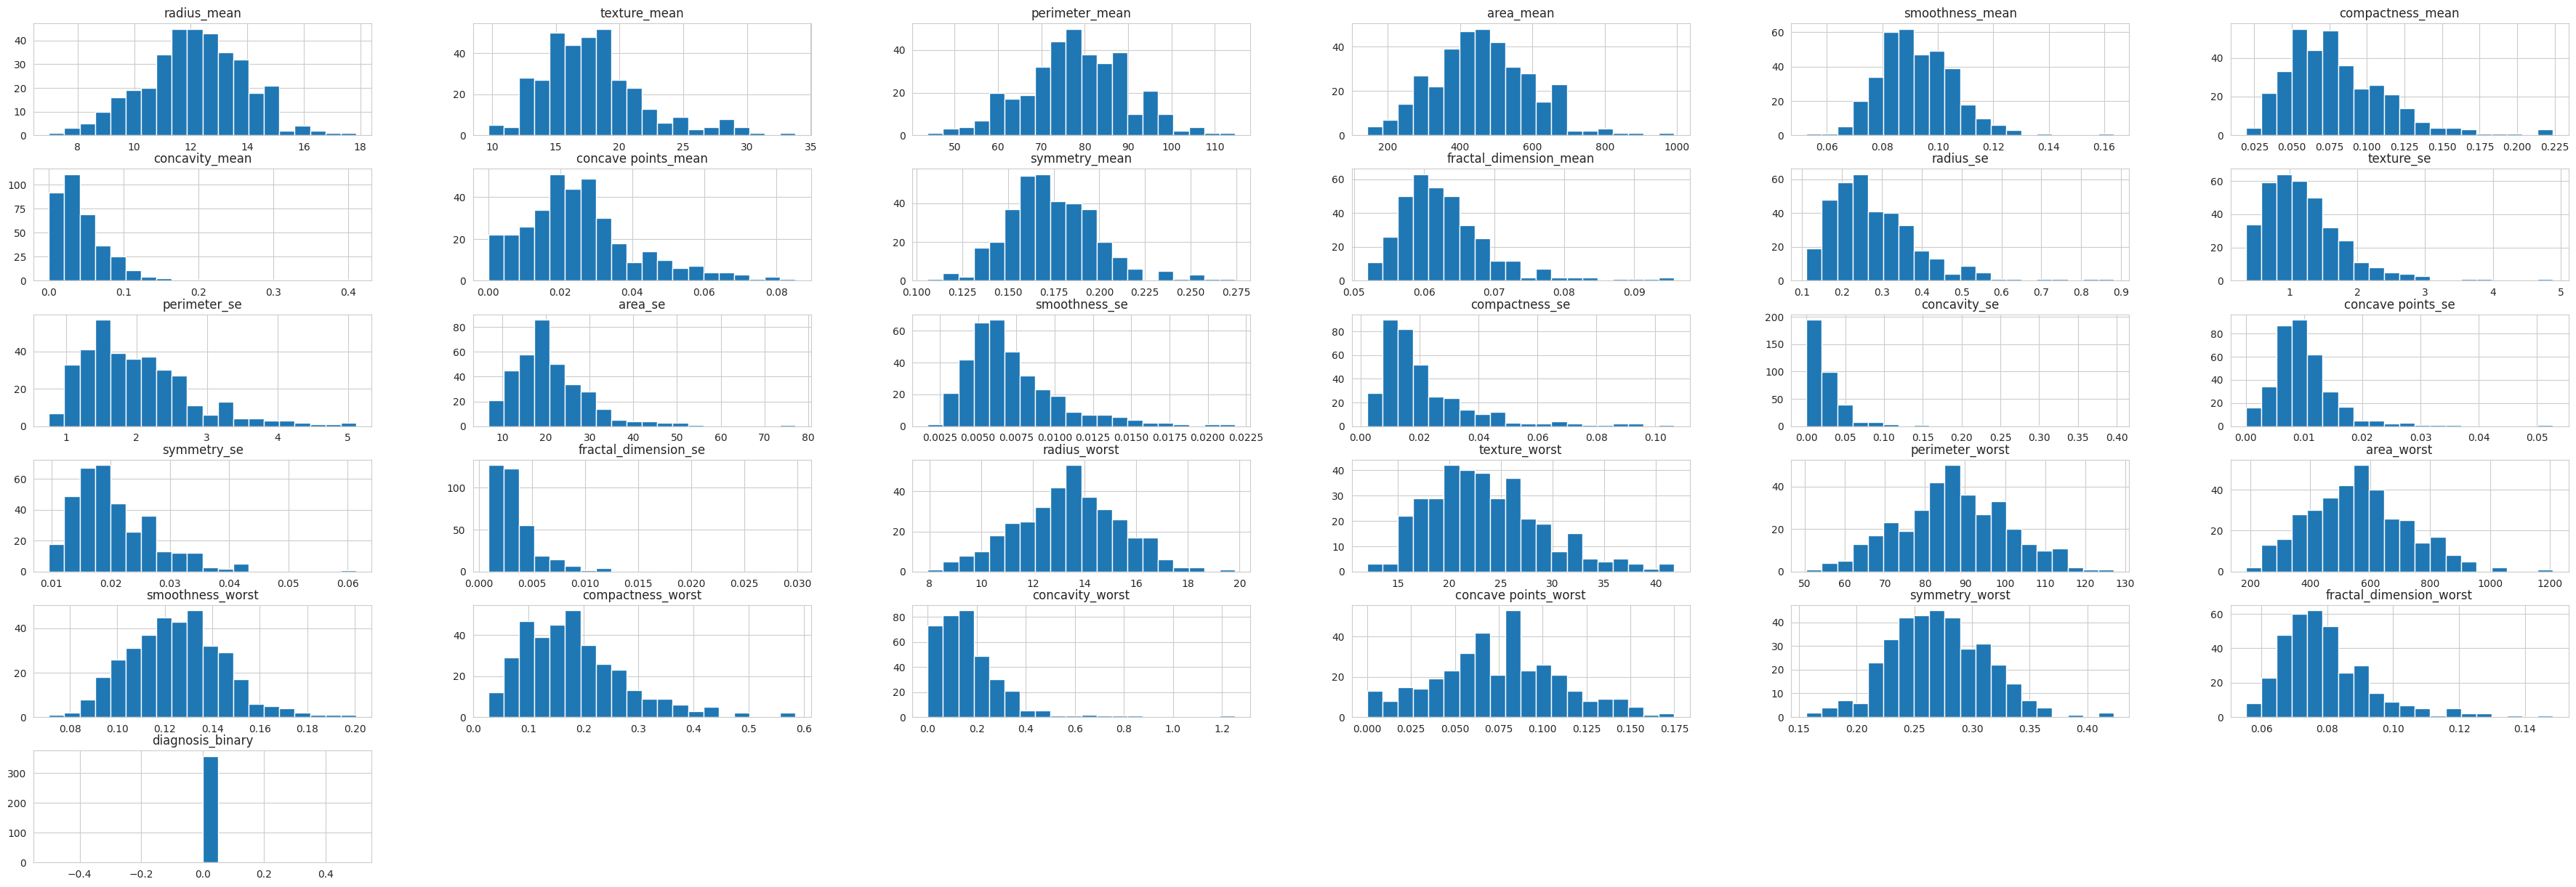

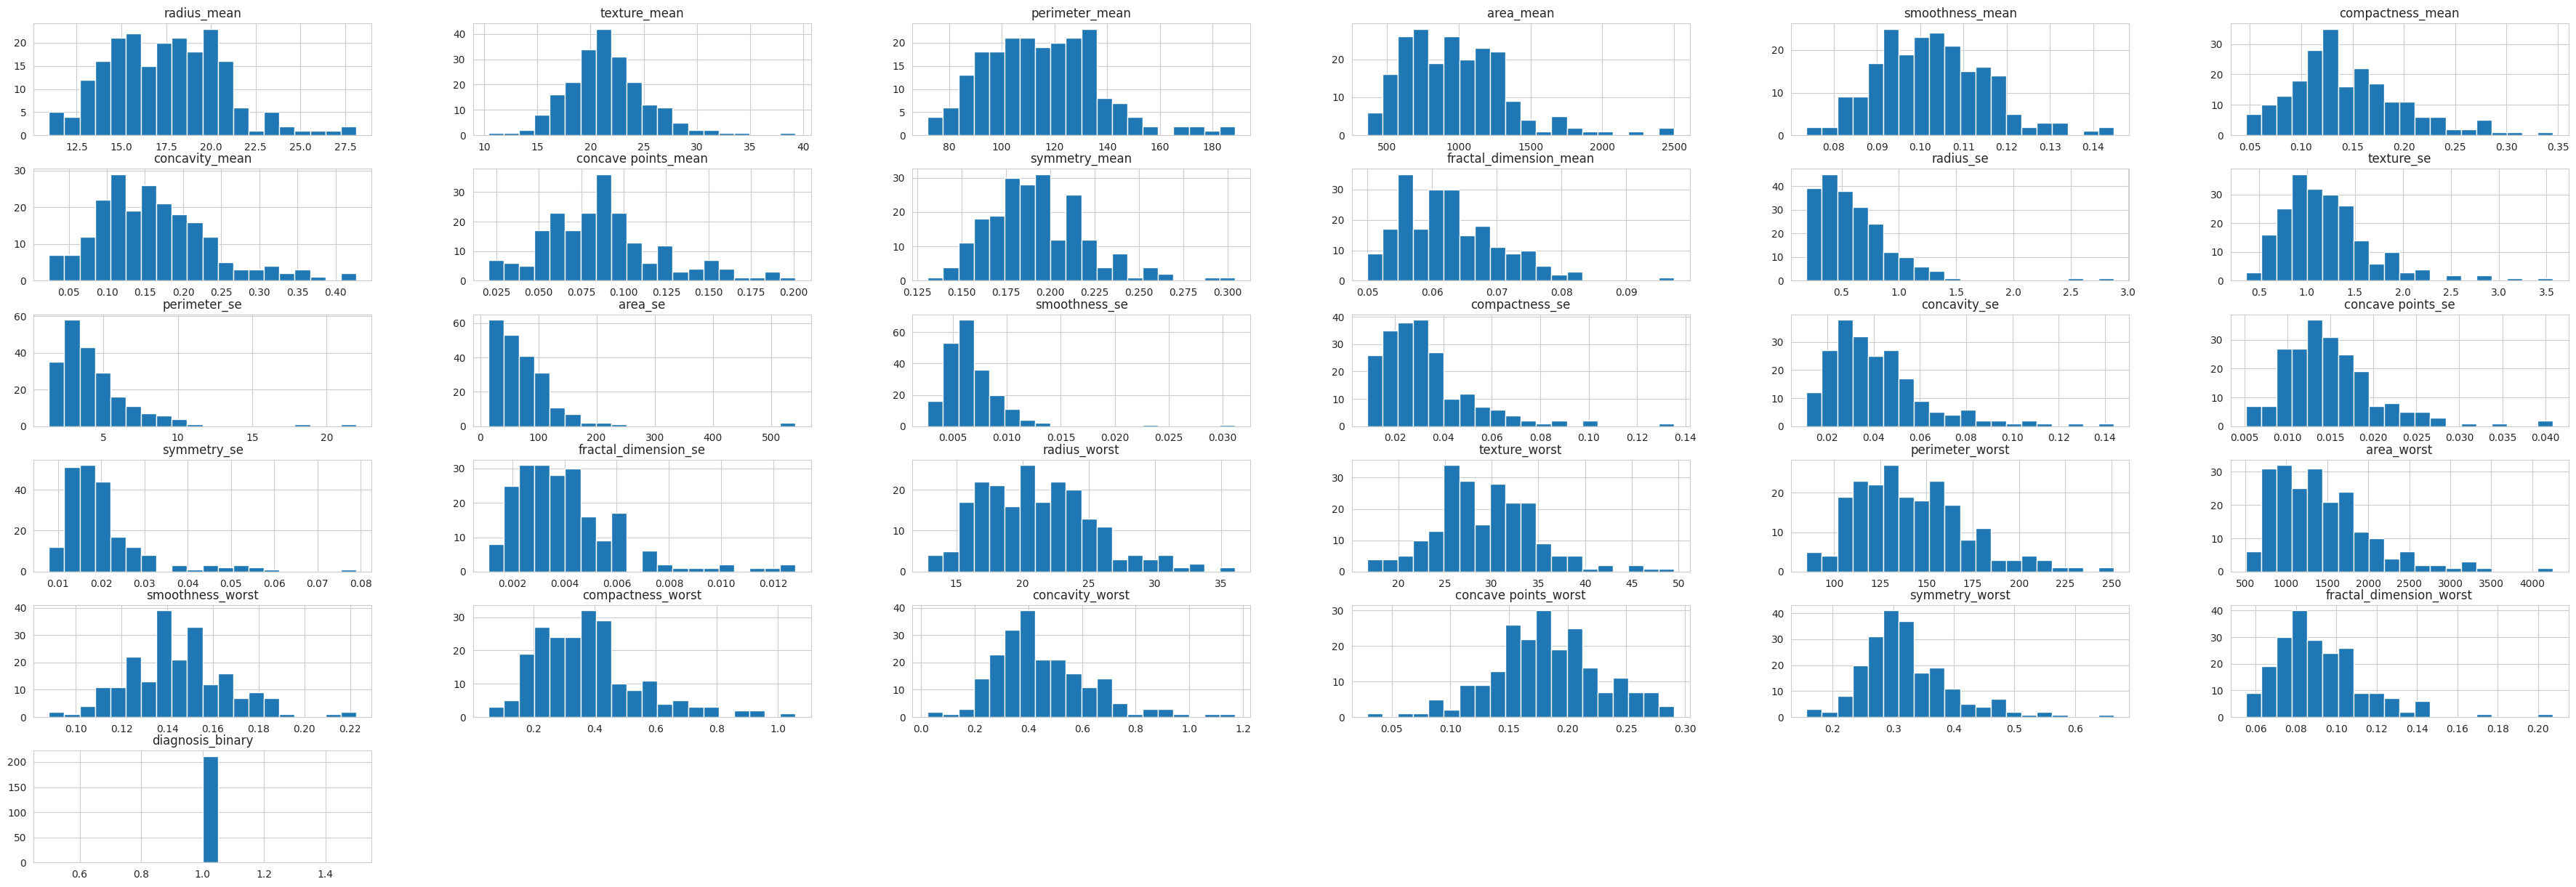

In [66]:
for diagnosis_binary in [0, 1]:
    subset = df_clean[df_clean['diagnosis_binary'] == diagnosis_binary]
    subset.hist(figsize=(45,15),bins=20)

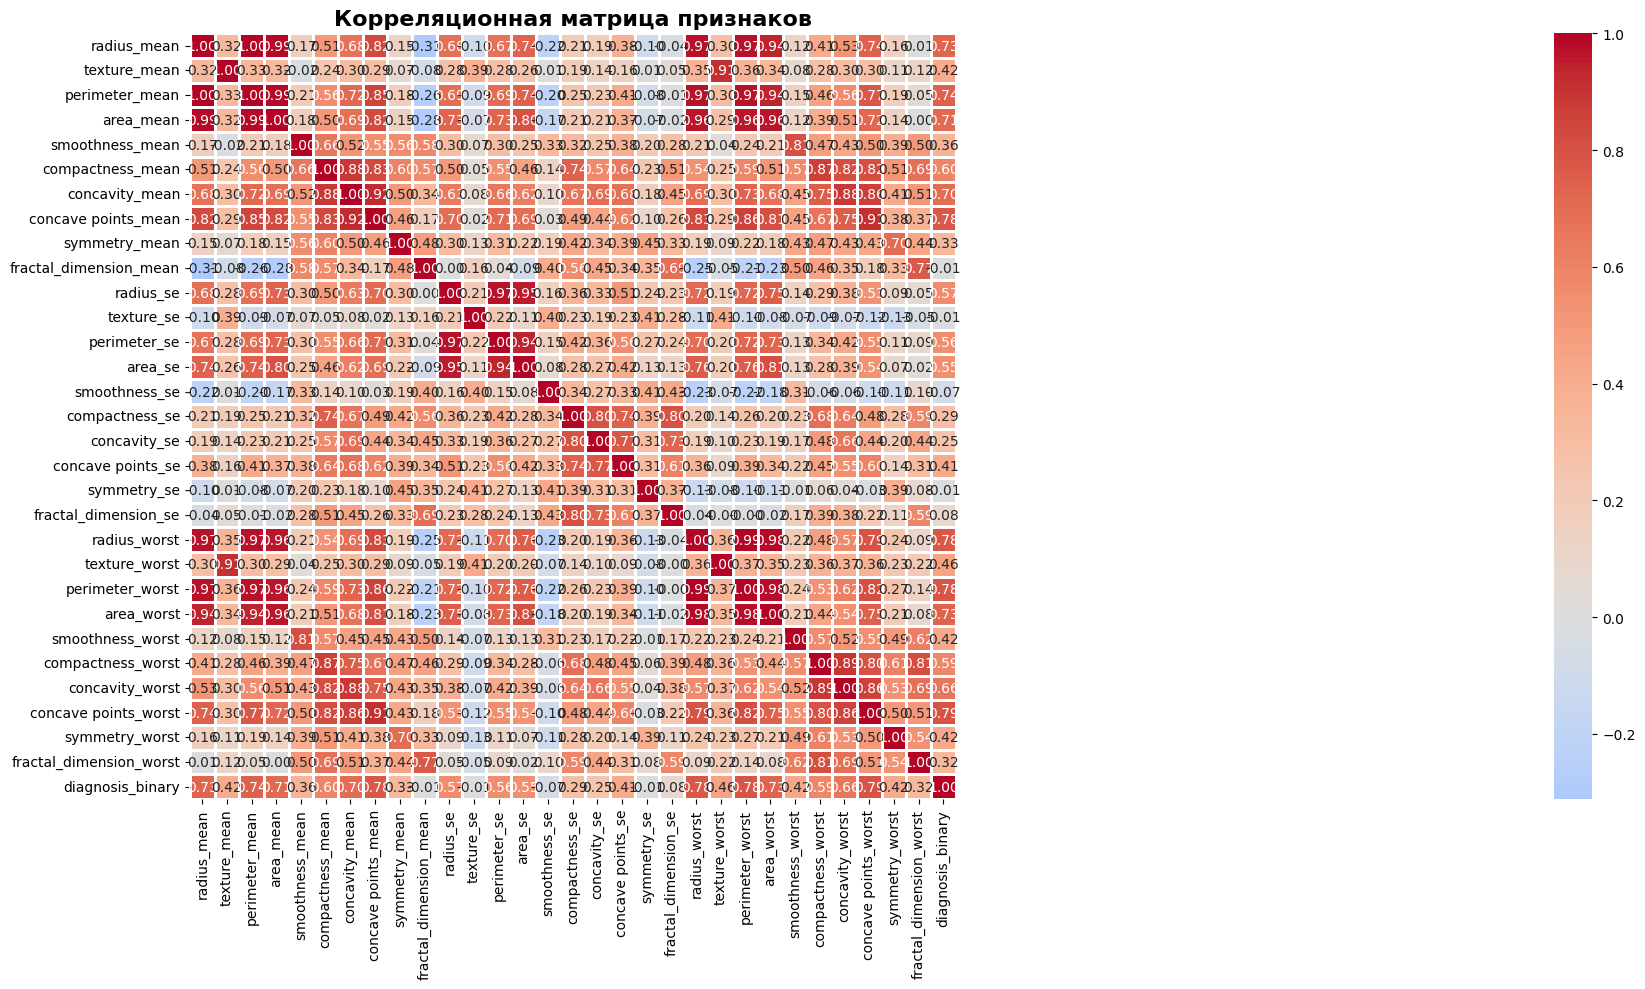

In [154]:
plt.figure(figsize=(120, 10))
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.9)
plt.title('Корреляционная матрица признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

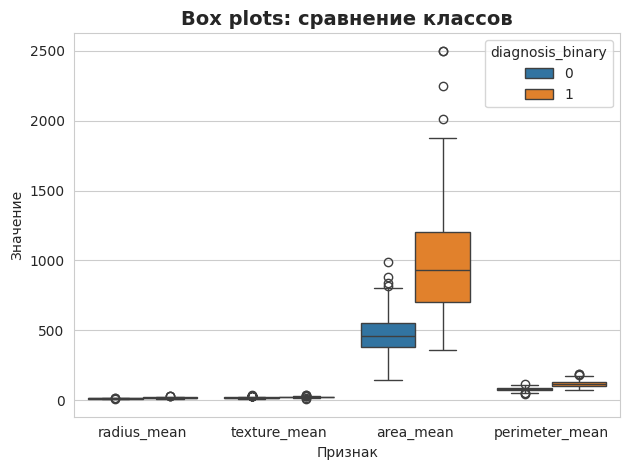

In [55]:
#Box plots для сравнения классов
df_melted = df_clean.melt(id_vars=['diagnosis_binary'],
                     value_vars=['radius_mean', 'texture_mean', 'area_mean','perimeter_mean'],
                     var_name='Признак', value_name='Значение')
sns.boxplot(x='Признак', y='Значение', hue='diagnosis_binary', data=df_melted)
plt.title('Box plots: сравнение классов', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

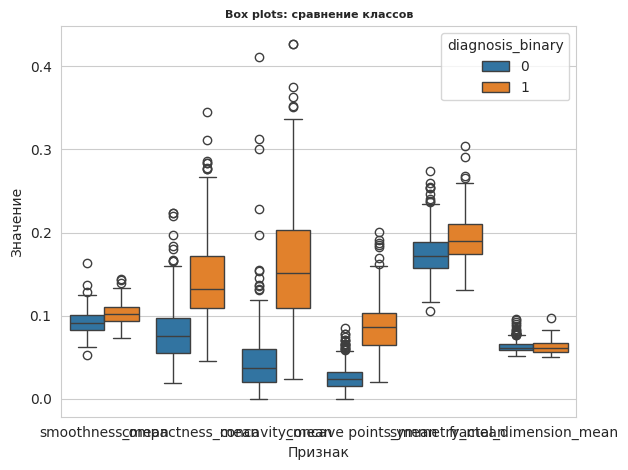

In [54]:
df_melted = df_clean.melt(id_vars=['diagnosis_binary'],value_vars=[ 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'],
                     var_name='Признак', value_name='Значение')
sns.boxplot(x='Признак', y='Значение', hue='diagnosis_binary', data=df_melted)
plt.title('Box plots: сравнение классов', fontsize=8, fontweight='bold')


plt.tight_layout()
plt.show()

In [40]:
for i, col in enumerate(df.columns):
    print(f"  Индекс {i}: '{col}'")

  Индекс 0: 'id'
  Индекс 1: 'diagnosis'
  Индекс 2: 'radius_mean'
  Индекс 3: 'texture_mean'
  Индекс 4: 'perimeter_mean'
  Индекс 5: 'area_mean'
  Индекс 6: 'smoothness_mean'
  Индекс 7: 'compactness_mean'
  Индекс 8: 'concavity_mean'
  Индекс 9: 'concave points_mean'
  Индекс 10: 'symmetry_mean'
  Индекс 11: 'fractal_dimension_mean'
  Индекс 12: 'radius_se'
  Индекс 13: 'texture_se'
  Индекс 14: 'perimeter_se'
  Индекс 15: 'area_se'
  Индекс 16: 'smoothness_se'
  Индекс 17: 'compactness_se'
  Индекс 18: 'concavity_se'
  Индекс 19: 'concave points_se'
  Индекс 20: 'symmetry_se'
  Индекс 21: 'fractal_dimension_se'
  Индекс 22: 'radius_worst'
  Индекс 23: 'texture_worst'
  Индекс 24: 'perimeter_worst'
  Индекс 25: 'area_worst'
  Индекс 26: 'smoothness_worst'
  Индекс 27: 'compactness_worst'
  Индекс 28: 'concavity_worst'
  Индекс 29: 'concave points_worst'
  Индекс 30: 'symmetry_worst'
  Индекс 31: 'fractal_dimension_worst'
  Индекс 32: 'Unnamed: 32'


📊 Все признаки в одной сетке 6×5
30


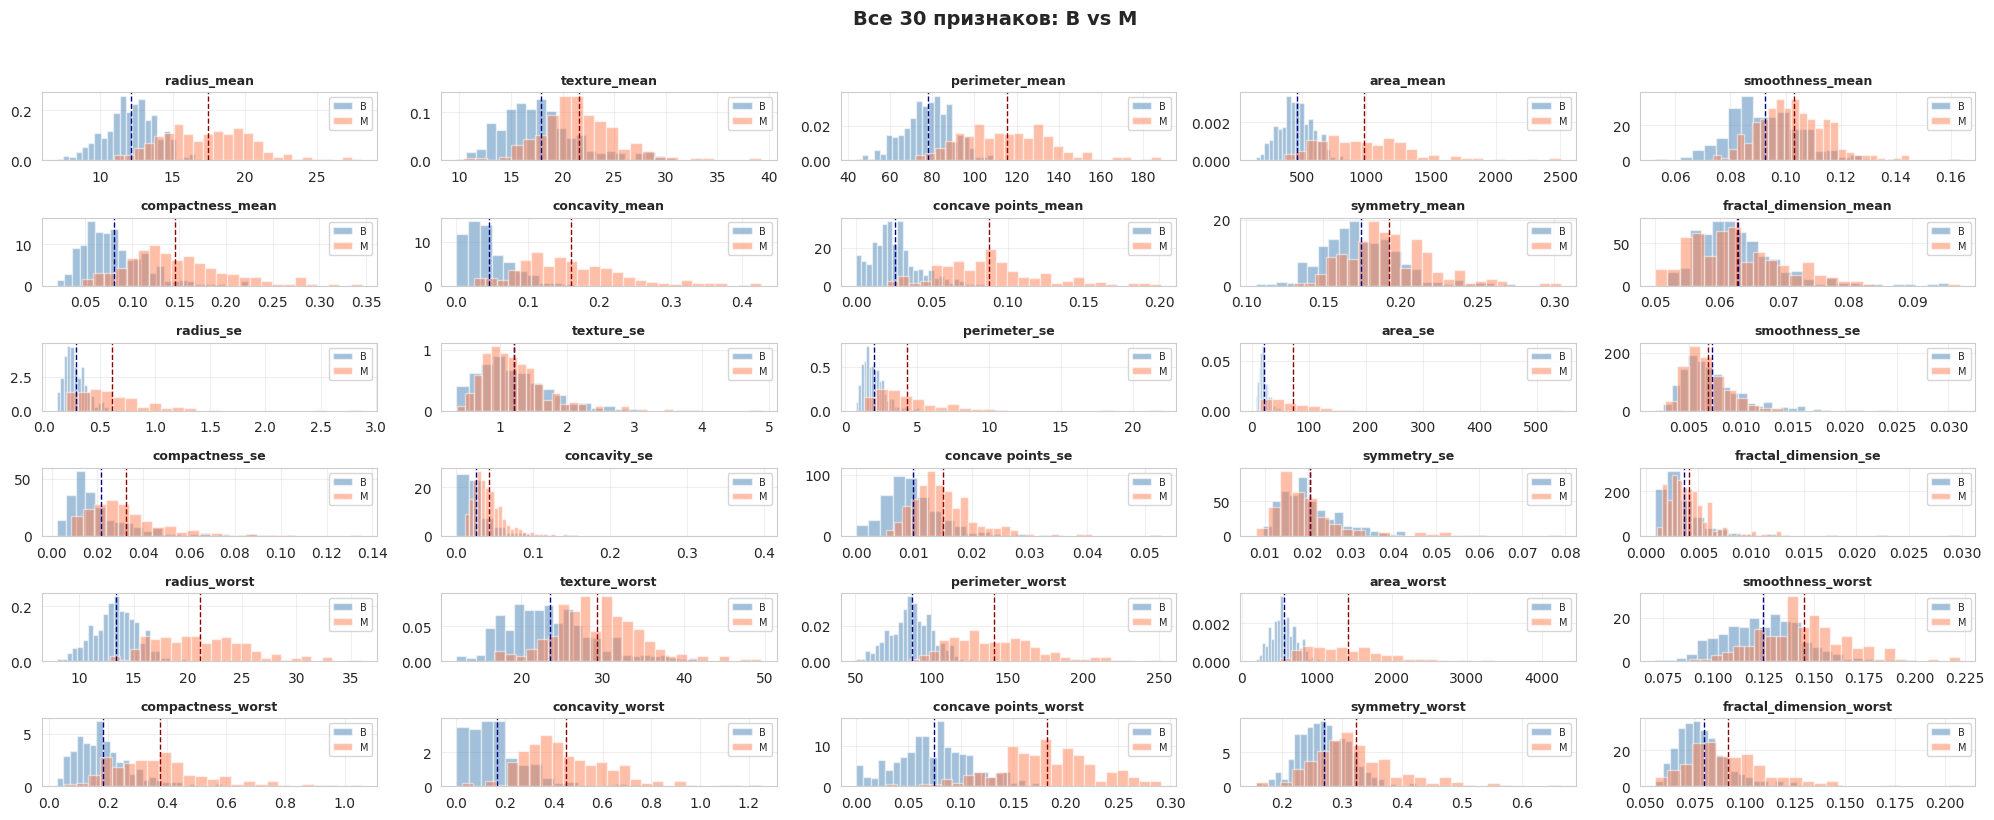

In [69]:


# Настройка
sns.set_style("whitegrid")
'''
features = [col for col in df_clean.columns if col not in ['diagnosis_binary']]
df_B = df_clean[df_clean['diagnosis_binary'] == '0']
df_M = df_clean[df_clean['diagnosis_binary'] == '1']
'''
features = [col for col in df.columns if col not in ['id', 'diagnosis','Unnamed: 32']]
df_B = df[df['diagnosis'] == 'B']
df_M = df[df['diagnosis'] == 'M']
# Функция для построения гистограммы одного признака
def plot_feature_histogram(feature, bins=20):
    plt.figure(figsize=(45, 15))

    # Гистограммы
    plt.hist(df_B[feature], bins=bins, alpha=0.6, color='steelblue',
             label='B (Доброкач.)', density=True, edgecolor='navy', linewidth=1)
    plt.hist(df_M[feature], bins=bins, alpha=0.6, color='coral',
             label='M (Злокач.)', density=True, edgecolor='darkred', linewidth=1)

    # Средние значения
    for data, color, style in [(df_B, 'navy', '--'), (df_M, 'darkred', '--')]:
        plt.axvline(data[feature].mean(), color=color, linestyle=style, linewidth=2, alpha=0.8)
        plt.axvline(data[feature].median(), color=color, linestyle=':', linewidth=1.5, alpha=0.5)

    # Статистика
    plt.text(0.98, 0.95, f'B: μ={df_B[feature].mean():.3f}, σ={df_B[feature].std():.3f}\n'
                         f'M: μ={df_M[feature].mean():.3f}, σ={df_M[feature].std():.3f}',
             transform=plt.gca().transAxes, fontsize=10, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.title(feature, fontsize=14, fontweight='bold')
    plt.xlabel('Значение'); plt.ylabel('Плотность')
    plt.legend(loc='upper left'); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# Функция для сетки графиков
def plot_features_grid(feature_list, rows, cols, title, figsize=(20, 8)):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for i, feature in enumerate(feature_list):
        axes[i].hist(df_B[feature], bins=25, alpha=0.5, color='steelblue', label='B', density=True)
        axes[i].hist(df_M[feature], bins=25, alpha=0.5, color='coral', label='M', density=True)
        axes[i].axvline(df_B[feature].mean(), color='navy', linestyle='--', linewidth=1)
        axes[i].axvline(df_M[feature].mean(), color='darkred', linestyle='--', linewidth=1)
        axes[i].set_title(feature, fontsize=9, fontweight='bold')
        axes[i].legend(fontsize=7); axes[i].grid(True, alpha=0.3)

    for i in range(len(feature_list), len(axes)):
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout();
    plt.show()

# 1. ВСЕ 30 ГРАФИКОВ В ОДНОЙ СЕТКЕ
print("📊 Все признаки в одной сетке 6×5")
print(len(features))
plot_features_grid(features, 6, 5, 'Все 30 признаков: B vs M')
